In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import sqlite3
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('predictive_maintenance.csv')
data.shape


(10000, 10)

In [3]:
data.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Target',
 'Failure Type']

In [4]:
data.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [5]:
data['Target'].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [6]:
data.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


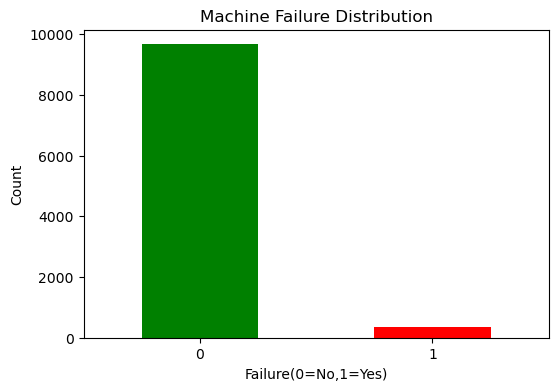

In [7]:
#Failure Distribution
plt.figure(figsize=(6,4)) 
data['Target'].value_counts().plot(kind='bar',color=['green','red'])
plt.title('Machine Failure Distribution')
plt.xlabel('Failure(0=No,1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

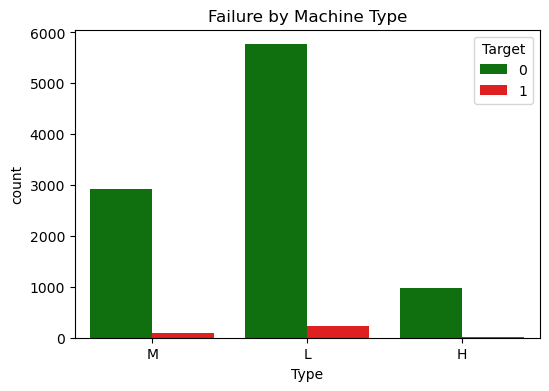

In [8]:
#failure By Machine Type
plt.figure(figsize=(6,4)) 
sns.countplot(x='Type',hue='Target',data=data,palette=['green','red'])
plt.title('Failure by Machine Type')
plt.show()

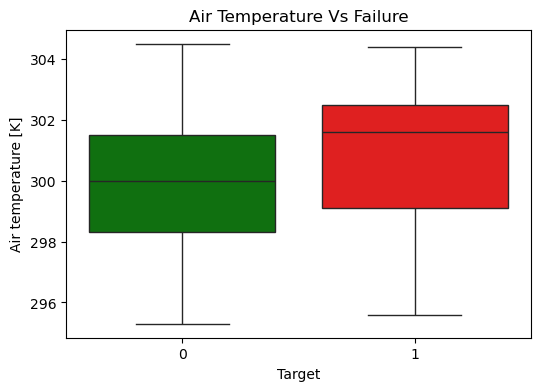

In [9]:
#Air temperature Vs failure
plt.figure(figsize=(6,4)) 
sns.boxplot(x='Target',y='Air temperature [K]',data=data,palette=['green','red'])
plt.title('Air Temperature Vs Failure')
plt.show()
#air temperature for systems that fail and Dont fail

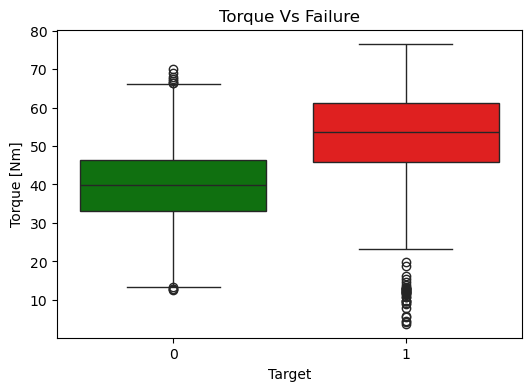

In [10]:
#Torque Vs failure
plt.figure(figsize=(6,4)) 
sns.boxplot(x='Target',y='Torque [Nm]',data=data,palette=['green','red'])
plt.title('Torque Vs Failure')
plt.show()
#rings are outliers
#so many machine with higher torqu also dont fail`,also machine with lower torque also fails

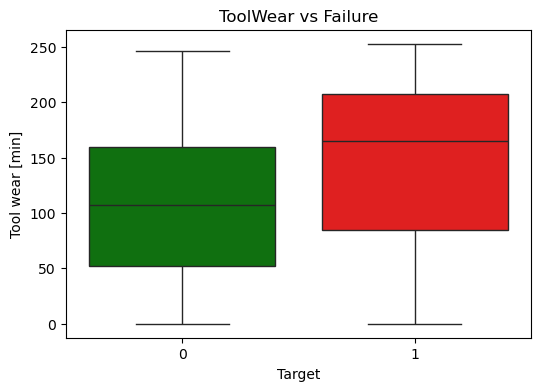

In [11]:
#ToolWear vs Failure
plt.figure(figsize=(6,4)) 
sns.boxplot(x='Target',y='Tool wear [min]',data=data,palette=['green','red'])
plt.title('ToolWear vs Failure')
plt.show()

In [12]:
data.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Target',
 'Failure Type']

In [13]:
data.drop(['UDI','Product ID','Failure Type'],axis=1,inplace=True)
data.shape

(10000, 7)

In [14]:
le=LabelEncoder()
data['Type']=le.fit_transform(data['Type'])

In [15]:
X=data.drop('Target',axis=1)
y=data['Target']

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
DT=DecisionTreeClassifier(random_state=42)
DT.fit(X_train,y_train)
DT_pred=DT.predict(X_test)
print("Decision Tree Accuracy:",accuracy_score(y_test,DT_pred))

Decision Tree Accuracy: 0.978


In [18]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
print("RandomForest Accuracy:",accuracy_score(y_test,rf_pred))

RandomForest Accuracy: 0.984


In [19]:
print("Classification Report - Random Forest:")
print(classification_report(y_test,rf_pred))

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.84      0.59      0.69        61

    accuracy                           0.98      2000
   macro avg       0.91      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [20]:
print("Confusion Matrix:")
print(confusion_matrix(y_test,rf_pred))

Confusion Matrix:
[[1932    7]
 [  25   36]]


Torque [Nm]                0.301376
Rotational speed [rpm]     0.230589
Tool wear [min]            0.167549
Air temperature [K]        0.144058
Process temperature [K]    0.128892
Type                       0.027536
dtype: float64


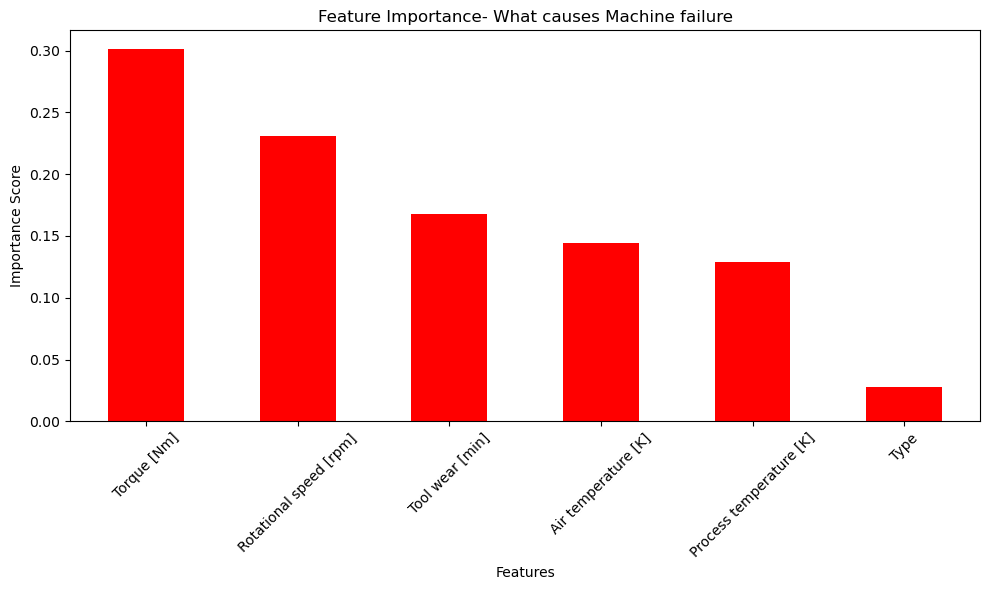

In [22]:
Feature_importance=pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
Feature_importance.plot(kind='bar',color='red')
plt.title('Feature Importance- What causes Machine failure')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show
print(Feature_importance)


In [23]:
joblib.dump(rf,'predictive_maintenance_model.pkl')
print("Model saved!")

Model saved!
